# Figure.1


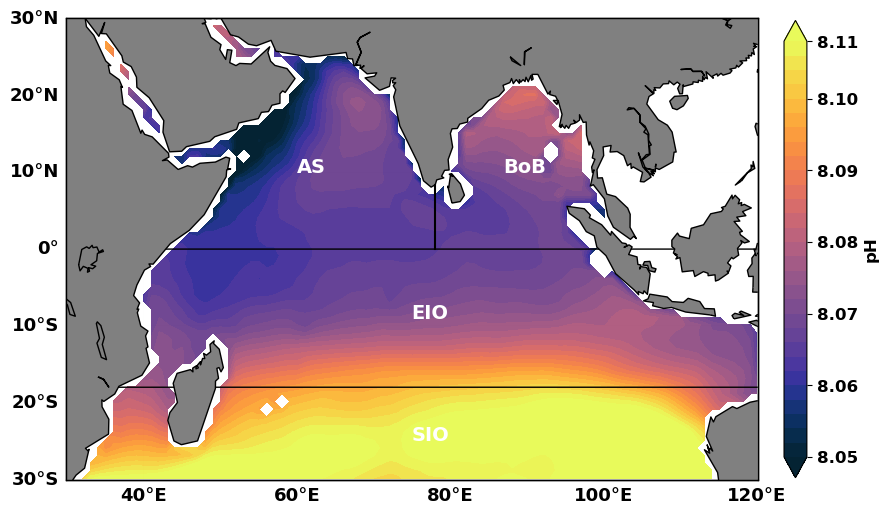

In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.colors as colors
from mpl_toolkits.basemap import Basemap
import numpy as np
import xarray as xr
import cmocean

ds1 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/CMEMS-LSCE-FFNN_ph.nc')
ds2 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Data_Scripts/data/OceanSODA_ph.nc')
lat_range = slice(-30, 30) 
lon_range = slice(30, 120) 

subset_ds1 = ds1.sel(lat=lat_range, lon=lon_range)
subset_ds2 = ds2.sel(lat=lat_range, lon=lon_range)

subset_ds1['time'] = subset_ds1.indexes['time'].to_period('M').to_timestamp()
subset_ds2['time'] = subset_ds2.indexes['time'].to_period('M').to_timestamp()

# Interpolate ds2 onto ds1 grid (lat, lon, time)
subset_ds2_interp = subset_ds2.interp(
    lat=subset_ds1['lat'],
    lon=subset_ds1['lon'],
    time=subset_ds1['time'],
    method='linear'
)

# Calculation of mean pH
ph_mean = xr.concat(
    [subset_ds1['ph'], subset_ds2_interp['ph']],
    dim='model'
).mean(dim='model')

ph_mean = ph_mean.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
ph_mean = ph_mean.mean('month')

l1 = np.arange(8.054, 8.059, 0.005)
l2 = np.arange(8.059, 8.076, 0.005)
l3 = np.arange(8.076, 8.09, 0.005)
l4 = np.arange(8.09, 8.115, 0.005)
l5 = np.concatenate((l1, l2, l3,l4))
norm11 = colors.BoundaryNorm(l5, ncolors=256)

cbar_num_format = "%.2f"

plt.figure(figsize=(12, 6))

cs = plt.contourf(
    ph_mean.lon, ph_mean.lat, ph_mean, levels=(np.arange(8.05, 8.11, 0.002)), 
    cmap=cmocean.cm.thermal, zorder=0, extend='both'
)

# Define colorbar
cbar = plt.colorbar(cs, label='pH', orientation='vertical', shrink=0.99, 
                    format=cbar_num_format, pad=-0.05, extend='both', aspect=20)

cbar.ax.tick_params(labelsize=12)
for label in cbar.ax.get_yticklabels():
    label.set_fontweight('bold')
cbar.ax.yaxis.label.set_weight('bold')
cbar.ax.yaxis.label.set_size('12')
cbar.set_ticks(np.arange(8.05, 8.111, 0.01))


m = Basemap(llcrnrlat=-30.1, urcrnrlat=30.1,
            llcrnrlon=30, urcrnrlon=120.1, resolution='c')


m.drawcoastlines()
m.fillcontinents(color='gray', lake_color='gray')
m.drawparallels(range(-30, 31, 10), linewidth=0.001, dashes=[4, 2], labels=[1, 0, 0, 1], color='black',
                 zorder=0, fontsize=13, fontweight='bold')
m.drawmeridians(range(40, 121, 20), labels=[1, 0, 0, 1], color='black', zorder=0, fontsize=13, fontweight='bold',
                 linewidth=0.001)
m.drawparallels([0, -18], linewidth=1, dashes=[4, 0], labels=[0, 0, 0, 0], color='black', zorder=0, fontsize=16,
                fontweight='bold')
# Draw line from 9°N to 0° along 75°E
m.plot(
    [78, 78],
    [8.4, 0],
    latlon=True,
    color='black',
    linewidth=1.5,
    linestyle='-',
    zorder=5
)

m.drawmapboundary(fill_color='white')

# Labels
plt.text(*m(60, 10), 'AS', fontsize=14, fontweight='bold', color='w')
plt.text(*m(87, 10), 'BoB', fontsize=14, fontweight='bold', color='w')
plt.text(*m(75, -9), 'EIO', fontsize=14, fontweight='bold', color='w')
plt.text(*m(75, -25), 'SIO', fontsize=14, fontweight='bold', color='w')
# plt.savefig('study_area_v2.png', bbox_inches = 'tight', dpi = 600)

plt.show()
